In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve

import tensorflow as tf
from tensorflow import keras

**Preprocessing Data**

In [2]:
df = pd.read_csv("creditcard.csv")

In [3]:
print("Shape: ", df.shape)
#df.shape is used to define the dataset shape

Shape:  (284807, 31)


In [4]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

**EDA**


Exploratory Data Analysis (EDA) is the process of analyzing, summarizing, and visualizing datasets to understand their structure, patterns, and anomalies. It detects outliers, handles missing values, and identifies key feature


In [5]:
#Detect Class Imbalance

class_counts = df["Class"].value_counts()
print("\nClass counts\n", class_counts)
print("\nClass %:\n", df["Class"].value_counts(normalize=True))


Class counts
 Class
0    284315
1       492
Name: count, dtype: int64

Class %:
 Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


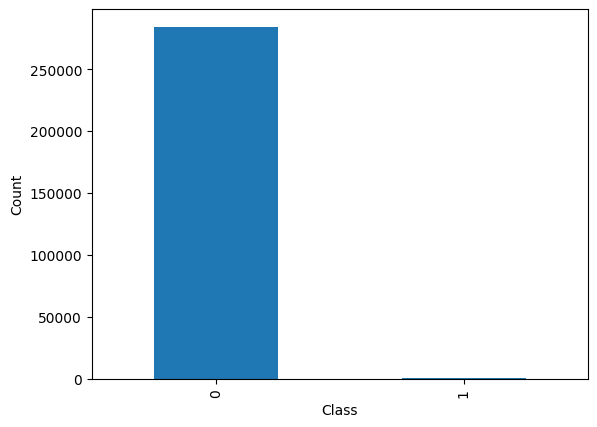

In [6]:
#Bar Chart
plt.figure()
class_counts.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Based on the Bar Chart, we can see that there is an imbalance in the data

In [7]:
#Detect Missing Value
missing_value = df.isna().sum()
print("\nMissing Values:\n", missing_value.sort_values(ascending=False).head(10)) # Print Top 10 Missing Values


Missing Values:
 Time    0
V1      0
V2      0
V3      0
V4      0
V5      0
V6      0
V7      0
V8      0
V9      0
dtype: int64


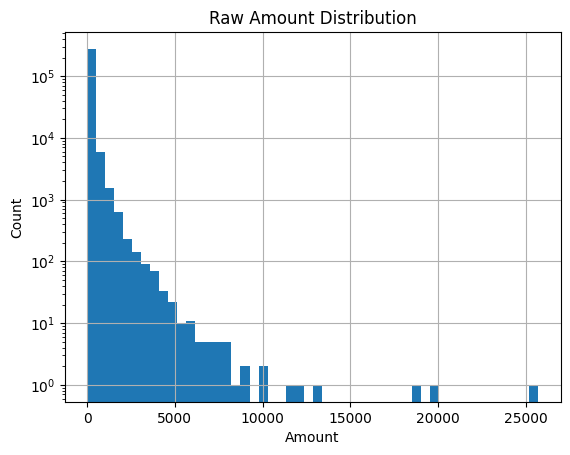

In [8]:
#Amount Distribution (skew)
plt.figure()
df["Amount"].hist(bins=50)
plt.title("Raw Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.yscale("log") #Make the skew visible
plt.show()

**Split the Dataset into X and Y**

In [9]:
y = df["Class"].astype(int).values #Label which tell us it's Fraud or not
x = df.drop(columns=["Class"]).copy() #Hold all the feature column where model allowed to learn from

**Scaling Time and Amount**

In [10]:
scaler = StandardScaler()
x[["Time", "Amount"]] = scaler.fit_transform(x[["Time", "Amount"]])

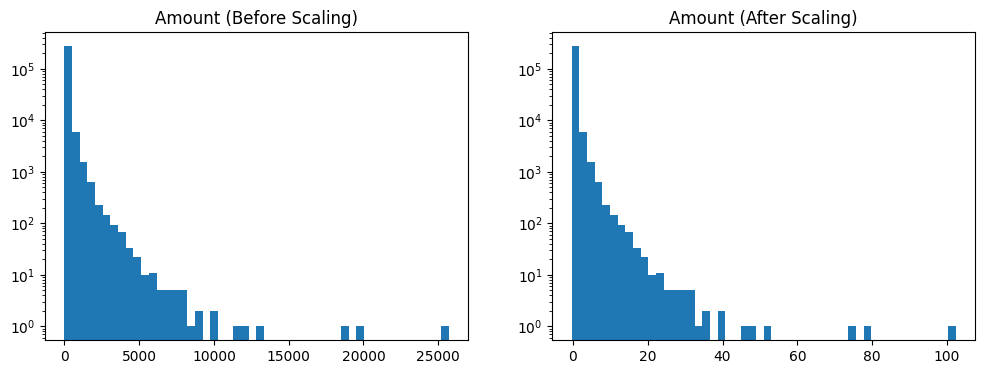

In [11]:
#Scaling doesn't change shape, just units
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Amount"], bins=50)
axes[0].set_title("Amount (Before Scaling)")
axes[0].set_yscale("log")

axes[1].hist(x["Amount"], bins=50)
axes[1].set_title("Amount (After Scaling)")
axes[1].set_yscale("log")

plt.show()

In [12]:
#Convert to numpy for Tensorflow
x = x.values.astype(np.float32)

**Split the Dataset into Train and Test Set**

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

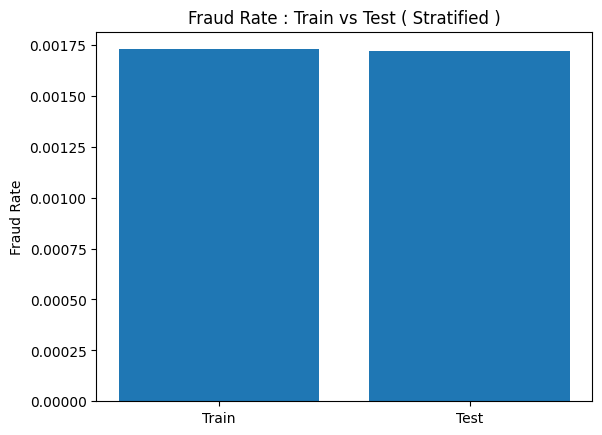

In [14]:
# Visual : fraud rate tsyas the same or similiar between train and test

train_rate = y_train.mean()
test_rate = y_test.mean()

plt.figure()
plt.bar(["Train", "Test"], [train_rate, test_rate])
plt.title("Fraud Rate : Train vs Test ( Stratified )")
plt.ylabel("Fraud Rate")
plt.show()

**Class Weight for Imbalance**


Class Weights:
 {0: 1.0, 1: np.float64(577.2868020304569)}

Train Fraud Rate :  0.001729245759178389


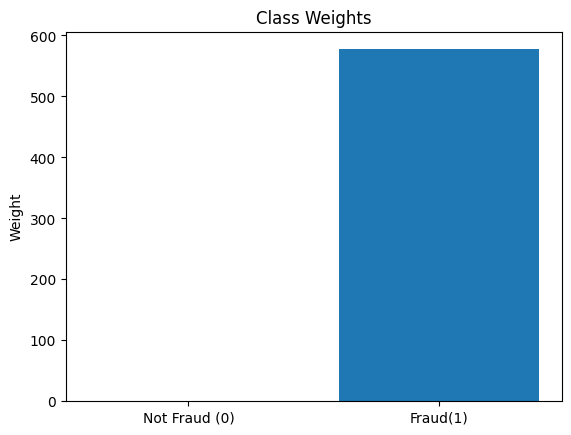

In [15]:
negative, positive = np.bincount(y_train)
class_weight = {0: 1.0, 1: negative / max(positive, 1)} # Avoid division by zero
print("\nClass Weights:\n", class_weight)
print("\nTrain Fraud Rate : ", positive / ( negative + positive ))

plt.figure()
plt.bar(["Not Fraud (0)", "Fraud(1)"], [class_weight[0], class_weight[1]])
plt.title("Class Weights")
plt.ylabel("Weight")
plt.show()

**Build Neural Network ( Simple MLP )**

In [16]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

**Compile Metrics that Matter for Fraud**

In [17]:
model.compile (
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss = "binary_crossentropy",
    metrics=[
        keras.metrics.AUC(curve="ROC", name="roc_auc"),
        keras.metrics.AUC(curve="PR", name="pr_auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode = "max",
        patience = 3,
        restore_best_weights=True
    )
]

**Training ( Watch Validation Metrics )**

Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7847 - pr_auc: 0.4074 - precision: 0.0068 - recall: 0.8778 - roc_auc: 0.9075 - val_loss: 0.2353 - val_pr_auc: 0.7479 - val_precision: 0.1723 - val_recall: 0.8554 - val_roc_auc: 0.9625
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4528 - pr_auc: 0.6165 - precision: 0.0469 - recall: 0.8810 - roc_auc: 0.9573 - val_loss: 0.1547 - val_pr_auc: 0.7457 - val_precision: 0.0983 - val_recall: 0.9036 - val_roc_auc: 0.9802
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3666 - pr_auc: 0.6015 - precision: 0.0464 - recall: 0.8971 - roc_auc: 0.9739 - val_loss: 0.1216 - val_pr_auc: 0.7190 - val_precision: 0.0840 - val_recall: 0.9157 - val_roc_auc: 0.9879
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3575 - pr_auc: 0.5297 - precision: 0.0464 - recall: 0.9035 - roc_auc: 0.9753 - val_loss: 0.1111 - val_pr_auc: 0.6903 - val_precision: 0.0832 - val_recall: 0.9157 - val_roc_auc: 0.9899


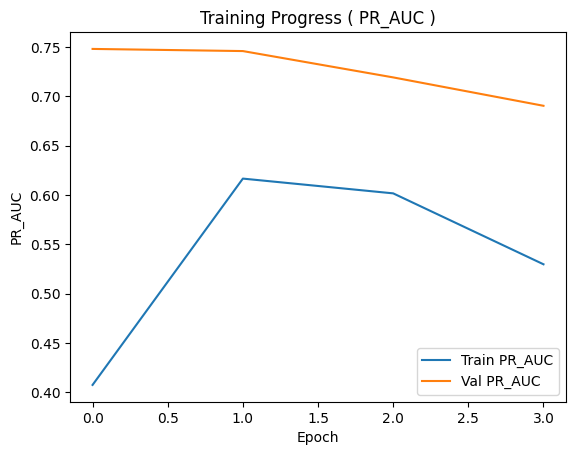

In [18]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

#Visualize Training History
plt.figure()
plt.plot(history.history["pr_auc"], label="Train PR_AUC")
plt.plot(history.history["val_pr_auc"], label="Val PR_AUC")
plt.title("Training Progress ( PR_AUC )")
plt.xlabel("Epoch")
plt.ylabel("PR_AUC")
plt.legend()
plt.show()

**Evaluate on NEVER-seen Test Set**


Test PR_AUC:  0.7033179008904664

=== Evaluation Report (Threshold = 0.5) ===
              precision    recall  f1-score   support

           0     0.9998    0.9919    0.9958     56864
           1     0.1566    0.8776    0.2658        98

    accuracy                         0.9917     56962
   macro avg     0.5782    0.9347    0.6308     56962
weighted avg     0.9983    0.9917    0.9946     56962

Confusion Matrix:
 [[56401   463]
 [   12    86]]


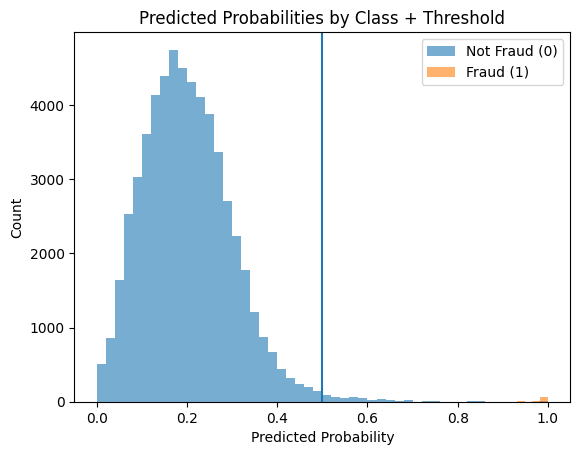

In [19]:
y_prob = model.predict(X_test, verbose=0).ravel()

test_pr_auc = average_precision_score(y_test, y_prob)
print("\nTest PR_AUC: ", test_pr_auc)

# Default threshold 0.5
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print("\n=== Evaluation Report (Threshold = 0.5) ===")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visual Probability Separation + Threshold Line
plt.figure()
plt.hist(y_prob[y_test == 0], bins=50, alpha=0.6, label="Not Fraud (0)")
plt.hist(y_prob[y_test == 1], bins=50, alpha=0.6, label="Fraud (1)")
plt.axvline(threshold)
plt.title("Predicted Probabilities by Class + Threshold")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

**Tune Threshold ( Cacth more Fraud accurately vs Fewer False Alarm )**

In [20]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

target_recall = 0.90
idxs = np.where(recall >= target_recall)[0]
if len(idxs) > 0:
    idx = idxs[-1]
    best_threshold = thresholds[idx] if idx < len(thresholds) else 0.5
    print(f"\n Threshold for {int(target_recall * 100)}% recall :", best_threshold)

    y_pred_tuned = (y_prob >= best_threshold).astype(int)
    print(f"\n=== Evaluation Report (Tuned Threshold = {best_threshold:.4f}) ===")
    print(classification_report(y_test, y_pred_tuned, digits=4))
    print("Confussion Matrix : \n", confusion_matrix(y_test, y_pred_tuned))
          
else:
    print(f"\nNo threshold found to achieve target recall with this model.")


 Threshold for 90% recall : 0.39712718

=== Evaluation Report (Tuned Threshold = 0.3971) ===
              precision    recall  f1-score   support

           0     0.9998    0.9667    0.9830     56864
           1     0.0449    0.9082    0.0855        98

    accuracy                         0.9666     56962
   macro avg     0.5224    0.9374    0.5343     56962
weighted avg     0.9982    0.9666    0.9814     56962

Confussion Matrix : 
 [[54970  1894]
 [    9    89]]


**Make Predictions**

In [22]:
results = pd.DataFrame({
    "prob_fraud": y_prob,
    "true_label": y_test
}).sort_values("prob_fraud", ascending=False)

print("\nTop 10 highest risk transaction:\n", results.head(10))


Top 10 highest risk transaction:
        prob_fraud  true_label
54930         1.0           1
51243         1.0           1
52728         1.0           1
35880         1.0           1
9730          1.0           1
19638         1.0           1
7299          1.0           1
42140         1.0           0
32115         1.0           1
37511         1.0           1


In [23]:
import json, os, pickle

In [24]:
os.makedirs("artifacts", exist_ok=True)

In [25]:
model.save("artifacts/model.keras")

In [26]:
with open ("artifacts/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [27]:
np.save("artifacts/X_test.npy", X_test)
np.save("artifacts/y_test.npy", y_test)

In [28]:
threshold_meta = {
    "best_threshold": float(best_threshold),
    "target_recall": float(target_recall),
    "test_pr_auc": float(test_pr_auc),
}

In [29]:
with open ("artifacts/threshold.json", "w") as f:
    json.dump(threshold_meta, f, indent=2)

In [30]:
print("\nArtifacts saved in 'artifacts/' directory.")


Artifacts saved in 'artifacts/' directory.
